# GFDL time series: forced-ocean parameterization comparison

Global-mean ocean temperature and salinity time series for GFDL's 4 forced-ocean
experiments (`CTRL`, `bANN`, `uANN`, `bANN_uANN`), testing the same `bANN`/`uANN`
buoyancy/momentum ANN parameterizations analyzed for CESM elsewhere in this repo.

**Scope**: this covers `thetao`/`so` only (temperature and salinity) -- GFDL's
postprocessed output here has no atmosphere, and sea-ice data only exists for
`CTRL`, so nothing coupled/ice/atmosphere-related is included. See
[`gfdl_shim.py`](../gfdl_shim.py) for how GFDL's own native-grid output is made
readable by this repo's `Experiment` class and `mom6_tools.TS_levels` without
copying/regridding GFDL's model data itself.

GFDL has no equivalent to CESM's online-computed `thetaoga`/`soga` scalar
diagnostics (`mom6_tools.stats`'s `-time_series` reads these directly from
MOM6's native history stream, which GFDL's postprocessing never wrote) --
the series here are volume-weighted means computed directly from GFDL's own
`thetao`/`so` + `volcello` (cell volume), see
[`gfdl_global_means.py`](../gfdl_global_means.py).

**Experiments compared**

| name | data folder | coverage |
|------|-------------|----------|
| `gfdl_CTRL` | `data/gfdl_45years` | 1958-2022 (gap 1963-1967) |
| `gfdl_bANN` | `data/gfdl_45years` | 1958-2012 |
| `gfdl_uANN` | `data/gfdl_45years` | 1963-2022 |
| `gfdl_bANN_uANN` | `data/gfdl_45years` | 1958-2022 (gapless) |

Coverage differs by experiment (a real limitation of the GFDL runs, not a
processing artifact) -- lines below simply stop where each experiment's own
data does.

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).


In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # lets matplotlib plot GFDL's cftime (julian calendar) axis directly

from experiment import Experiment

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 16})

# Repo-root-relative paths (this notebook lives in <repo>/notebooks)
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
GFDL_DIR = os.path.join(REPO, 'data', 'gfdl_45years')

print('REPO     =', REPO)
print('YAML_DIR =', YAML_DIR)
print('GFDL_DIR =', GFDL_DIR)


REPO     = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
YAML_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/yamls
GFDL_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/gfdl_45years


## Initialize experiments (read-only)

Each experiment is defined by its `name`, the diagnostics YAML config, and the
folder holding its postprocessed NetCDF files. Initialization is read-only: it
only reads config + grid, and never triggers heavy computation. The GFDL grid
is regular 1x1 degree (not curvilinear/tripolar like CESM's), which is why the
plotting helpers below are simpler than the CESM notebooks' -- no tripolar-safe
binning or C-grid corner points needed.


In [2]:
# (name, folder) for each experiment. YAML config is yamls/<name>.yaml
experiment_defs = [
    ('gfdl_CTRL',       GFDL_DIR),
    ('gfdl_bANN',       GFDL_DIR),
    ('gfdl_uANN',       GFDL_DIR),
    ('gfdl_bANN_uANN',  GFDL_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

names = list(exps.keys())

# Short legend labels
LABELS = {
    'gfdl_CTRL':      'noGM',
    'gfdl_bANN':      'bANN',
    'gfdl_uANN':      'uANN',
    'gfdl_bANN_uANN': 'bANN_uANN',
}

# Fixed, colorblind-safe categorical colors (Okabe & Ito 2008), one per
# experiment, assigned in a fixed order and reused across every plot.
COLORS = {
    'gfdl_CTRL':     'k',
    'gfdl_bANN':     'tab:blue',
    'gfdl_uANN':      'tab:green',  # green
    'gfdl_bANN_uANN': 'tab:orange'
}

print('Initialized:', names)


[gfdl_CTRL] casename=gfdl_CTRL, rundir=/glade/derecho/scratch/pavelp/GFDL/CTRL/cesm_format/run


ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


MOM6 grid successfully loaded... 

[gfdl_bANN] casename=gfdl_bANN, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN/cesm_format/run
MOM6 grid successfully loaded... 

[gfdl_uANN] casename=gfdl_uANN, rundir=/glade/derecho/scratch/pavelp/GFDL/uANN/cesm_format/run
MOM6 grid successfully loaded... 

[gfdl_bANN_uANN] casename=gfdl_bANN_uANN, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN_uANN/cesm_format/run
MOM6 grid successfully loaded... 

Initialized: ['gfdl_CTRL', 'gfdl_bANN', 'gfdl_uANN', 'gfdl_bANN_uANN']


# 1. Global-mean ocean temperature

Volume-weighted global-mean potential temperature, $\theta_{ga}$, monthly time series.


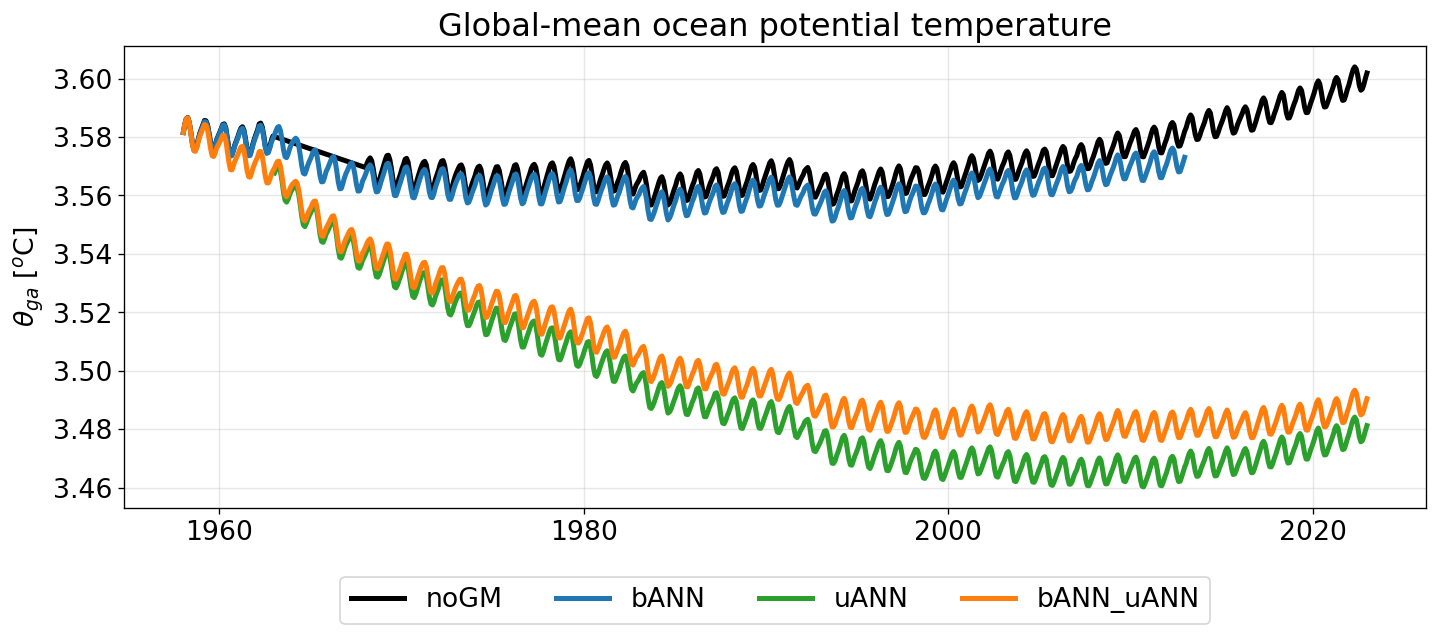

In [5]:
fig, ax = plt.subplots(figsize=(14, 5), dpi=120)
for name in names:
    gm = exps[name].global_means()
    if name == 'gfdl_CTRL':
        pass#gm = gm.sel(time=slice('1965','2030'))
    ax.plot(gm.time.values, gm.thetaoga.values[:, 0], color=COLORS[name],
            label=LABELS[name], lw=3)
ax.set_ylabel(r'$\theta_{ga}$ [$^o$C]')
ax.set_title('Global-mean ocean potential temperature')
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.12))
ax.grid(alpha=0.3)
plt.show()

# 2. Global-mean ocean salinity

Volume-weighted global-mean practical salinity, $S_{ga}$, monthly time series.


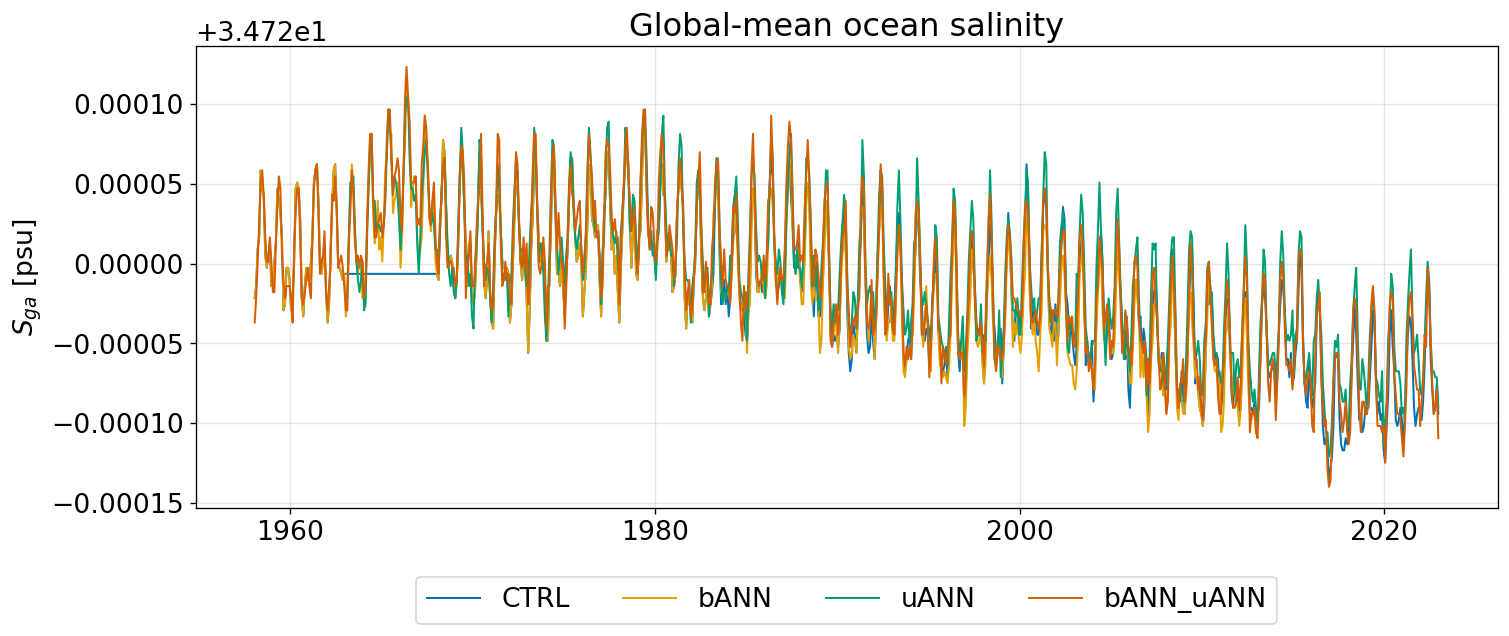

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5), dpi=120)
for name in names:
    gm = exps[name].global_means()
    ax.plot(gm.time.values, gm.soga.values[:, 0], color=COLORS[name],
            label=LABELS[name], lw=1.2)
ax.set_ylabel(r'$S_{ga}$ [psu]')
ax.set_title('Global-mean ocean salinity')
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.12))
ax.grid(alpha=0.3)
plt.show()
